In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [50]:
df= pd.read_csv('laporan_harian_pullet.csv')
df

,tanggal,kandang,umur_hari,minggu,populasi,mati,afkir,populasi_akhir,pakan_kg,fi_aktual_gr,fi_std_gr,jenis_feed,vaksin
0,2026-01-01,K01,1,1,1000,1,0,999,13.89,13.9,14,Starter,ND-IB
1,2026-01-02,K01,2,1,999,0,0,999,13.70,13.7,14,Starter,NaN
2,2026-01-03,K01,3,1,999,0,0,999,14.29,14.3,14,Starter,NaN
3,2026-01-04,K01,4,1,999,2,0,997,13.58,13.6,14,Starter,NaN
4,2026-01-05,K01,5,1,997,0,0,997,13.69,13.7,14,Starter,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,2026-04-18,K05,108,16,976,0,0,976,86.51,88.6,91,Developer,NaN
556,2026-04-19,K05,109,16,976,0,0,976,90.08,92.3,91,Developer,NaN
557,2026-04-20,K05,110,16,976,0,0,976,86.37,88.5,91,Developer,NaN
558,2026-04-21,K05,111,16,976,0,0,976,86.54,88.7,91,Developer,NaN


In [51]:
df2= pd.read_csv('laporan_sampling_pullet.csv')
df2

,kandang,minggu,umur_hari,bobot_gram,berat_std_gr
0,K01,1,7,122.1,110
1,K01,1,7,103.4,110
2,K01,1,7,99.4,110
3,K01,1,7,115.4,110
4,K01,1,7,122.0,110
...,...,...,...,...,...
3891,K05,16,112,857.3,1260
3892,K05,16,112,1387.8,1260
3893,K05,16,112,1157.4,1260
3894,K05,16,112,1305.9,1260


In [52]:
#bobot rata rata perkandang permingu dengan std dan jumlah sampel ditimbang
stat_pullet = df2.groupby(['kandang','minggu']).agg(
    bobot_rata = ('bobot_gram','mean'),
    bobot_std = ('bobot_gram','std'),
    jumlah_sampel = ('bobot_gram','count')
)
print('='*80)
print('Bobot rata rata perkandang permingu dengan std dan jumlah sampel ditimbang')
print('='*80)
print(stat_pullet.head(16))

Bobot rata rata perkandang permingu dengan std dan jumlah sampel ditimbang
                 bobot_rata   bobot_std  jumlah_sampel
kandang minggu                                        
K01     1        112.210204    9.489671             49
        2        193.273469   21.248459             49
        3        269.920408   30.038399             49
        4        348.965306   36.823241             49
        5        437.161224   42.113135             49
        6        459.732653   53.741396             49
        7        551.722449   53.661506             49
        8        619.344898   71.930771             49
        9        684.281633   66.365785             49
        10       763.551020   88.916501             49
        11       866.148980   92.193472             49
        12       960.946939   94.813864             49
        13      1006.943750   88.033584             48
        14      1101.602083  126.171428             48
        15      1177.187500   92.699507      

In [53]:
#std setiap minggu semua kandang
pooled = stat_pullet.groupby('minggu').apply(
    lambda g: np.sqrt(
        ((g['jumlah_sampel'] - 1) * g['bobot_std']**2).sum() /
        (g['jumlah_sampel'].sum() - len(g))
    )
).reset_index(name='pooled_std')
print('='*50)
print('STD setiap minggu semua kandang')
print('='*50)
print(pooled)

STD setiap minggu semua kandang
    minggu  pooled_std
0        1   11.197688
1        2   18.925363
2        3   25.185484
3        4   35.957201
4        5   46.609882
5        6   45.853857
6        7   52.821948
7        8   65.138082
8        9   70.352486
9       10   80.859534
10      11   87.469535
11      12   93.940312
12      13  101.026327
13      14  113.656691
14      15  112.101234
15      16  110.218275


In [54]:
#standar_hyline
standar_hyline = pd.DataFrame({
    'minggu': list(range(1, 18)),
    'bawah': [70, 115, 190, 270, 360, 470, 570, 680, 780, 885, 995, 1095, 1175, 1265, 1345, 1410, 1485],
    'atas': [80, 145, 220, 320, 420, 520, 640, 760, 880, 995, 1105, 1205, 1295, 1365, 1445, 1510, 1590]
})
standar_hyline = standar_hyline[standar_hyline['minggu'] <= 16]


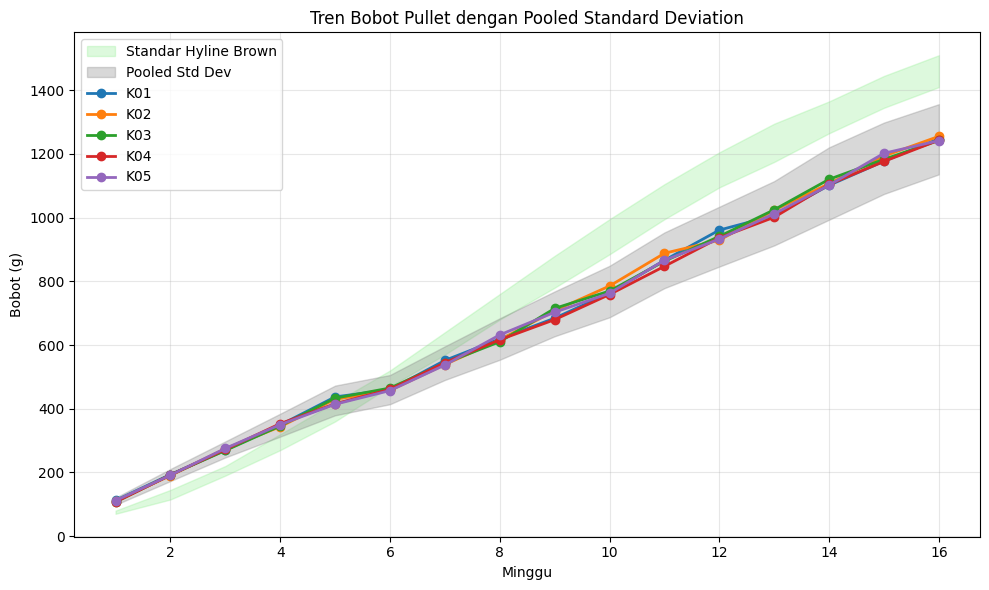

In [55]:
#Tren Bobot Pullet dengan Pooled Standard Deviation
stat_pullet = stat_pullet.reset_index()

global_mean = stat_pullet.groupby('minggu').apply(
    lambda g: np.average(g['bobot_rata'], weights=g['jumlah_sampel'])
).reset_index(name='global_mean')

global_data = global_mean.merge(pooled, on='minggu')

plt.figure(figsize=(10, 6))

plt.fill_between(standar_hyline['minggu'],
                 standar_hyline['bawah'],
                 standar_hyline['atas'],
                 alpha=0.3, color='lightgreen',
                 label='Standar Hyline Brown')

plt.fill_between(global_data['minggu'],
                 global_data['global_mean'] - global_data['pooled_std'],
                 global_data['global_mean'] + global_data['pooled_std'],
                 alpha=0.3, color='gray', label='Pooled Std Dev')

for kandang in stat_pullet['kandang'].unique()[:5]:
    data = stat_pullet[stat_pullet['kandang'] == kandang]
    plt.plot(data['minggu'], data['bobot_rata'],
             marker='o', linewidth=2, label=kandang)

plt.xlabel('Minggu')
plt.ylabel('Bobot (g)')
plt.title('Tren Bobot Pullet dengan Pooled Standard Deviation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
#Koefisien variasi
stat_pullet['cv'] = ((stat_pullet['bobot_std']/stat_pullet['bobot_rata'])*100 )
print('='*50)
print('Koefisien variasi')
print('='*50)
print(stat_pullet['cv'].head(17))

Koefisien variasi
0      8.457048
1     10.993986
2     11.128613
3     10.552121
4      9.633319
5     11.689706
6      9.726178
7     11.614009
8      9.698607
9     11.645129
10    10.644066
11     9.866712
12     8.742652
13    11.453449
14     7.874659
15     9.317916
16     8.698177
Name: cv, dtype: float64


In [77]:
# Filter minggu 16
cv_minggu16 = stat_pullet[stat_pullet['minggu'] == 16][['kandang', 'minggu', 'bobot_rata', 'bobot_std', 'cv']]

print('='*50)
print('KOEFISIEN VARIASI (CV) MINGGU 16')
print('='*50)
print(cv_minggu16.to_string(index=False))

# Rata-rata CV
print(f"\nRata-rata CV minggu 16: {cv_minggu16['cv'].mean():.2f}%")

KOEFISIEN VARIASI (CV) MINGGU 16
kandang  minggu  bobot_rata  bobot_std       cv
    K01      16 1247.906250 116.278851 9.317916
    K02      16 1255.339583 109.954969 8.758982
    K03      16 1242.630612  97.652437 7.858525
    K04      16 1243.339583 116.366188 9.359164
    K05      16 1241.829167 110.036185 8.860815

Rata-rata CV minggu 16: 8.83%


In [78]:
# keseregaman perkandang perminggu
def keseragaman(grup) :
    rata = grup['bobot_gram'].mean()
    batas_bawah = rata * 0.9
    batas_atas = rata * 1.1
    dalam_rentang = grup[(grup['bobot_gram'] >= batas_bawah) & (grup['bobot_gram'] <= batas_atas)]
    return len(dalam_rentang)/len(grup) * 100 

keseragaman_perkandang_perminggu = df2.groupby(['kandang', 'minggu']).apply(keseragaman).reset_index(name = 'keseragaman')
print('='*50)
print('Keseregaman perkandang perminggu')
print('='*50)

print(keseragaman_perkandang_perminggu.head())

Keseregaman perkandang perminggu
  kandang  minggu  keseragaman
0     K01       1    77.551020
1     K01       2    63.265306
2     K01       3    61.224490
3     K01       4    71.428571
4     K01       5    71.428571


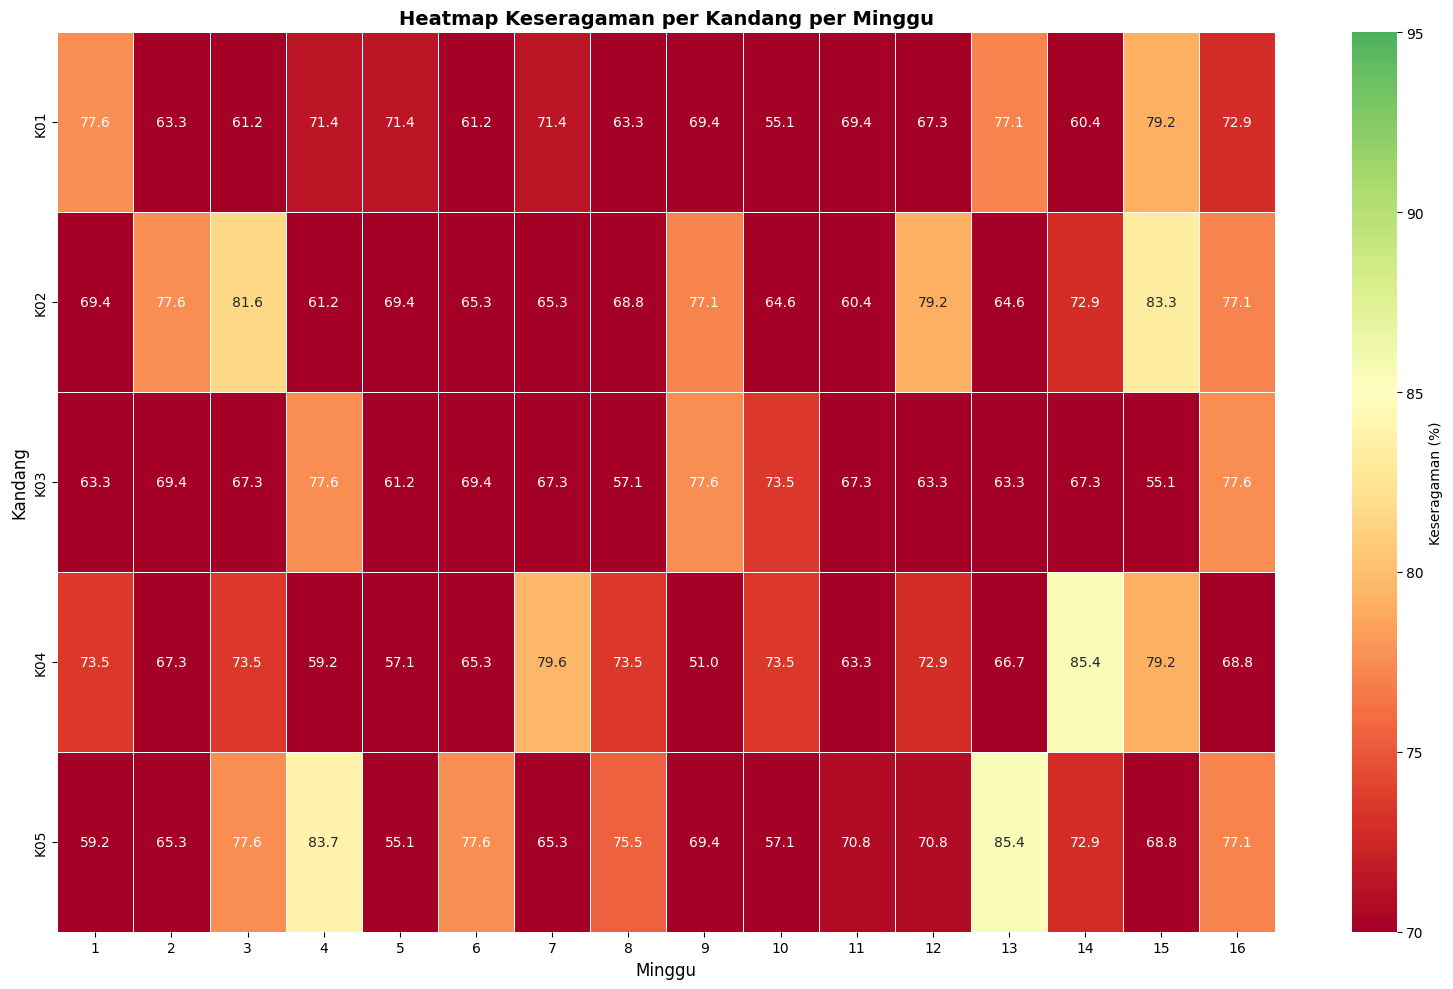

In [79]:
# heatmap keseragaman
pivot_keseragaman = keseragaman_perkandang_perminggu.pivot(index='kandang', columns='minggu', values='keseragaman')

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_keseragaman, annot=True, fmt='.1f', 
            cmap='RdYlGn', center=85, vmin=70, vmax=95,
            linewidths=0.5, cbar_kws={'label': 'Keseragaman (%)'})
plt.title('Heatmap Keseragaman per Kandang per Minggu', fontsize=14, fontweight='bold')
plt.xlabel('Minggu', fontsize=12)
plt.ylabel('Kandang', fontsize=12)
plt.tight_layout()
plt.show()

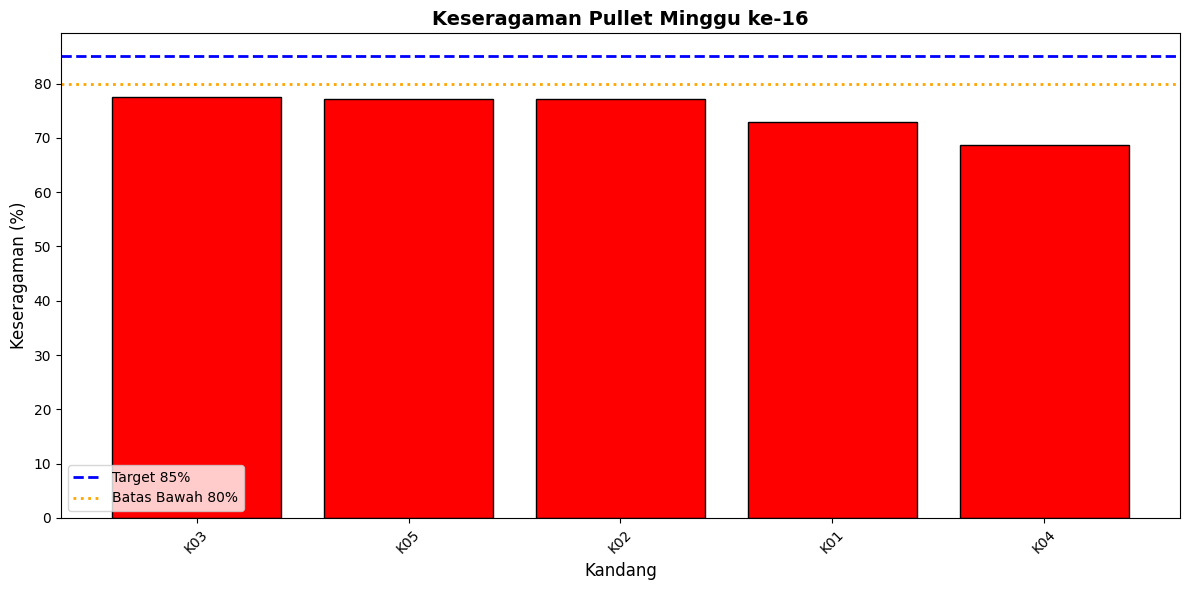

In [80]:
#keseragaman akhir minggu ke 16 per kandang
df_akhir = keseragaman_perkandang_perminggu[keseragaman_perkandang_perminggu['minggu'] == 16].copy()

df_akhir = df_akhir.sort_values('keseragaman', ascending=False)

colors = []
for nilai in df_akhir['keseragaman']:
    if nilai >= 85:
        colors.append('green')
    elif nilai >= 80:
        colors.append('orange')
    else:
        colors.append('red')

plt.figure(figsize=(12, 6))
bars = plt.bar(df_akhir['kandang'], df_akhir['keseragaman'], color=colors, edgecolor='black')

plt.axhline(y=85, color='blue', linestyle='--', linewidth=2, label='Target 85%')
plt.axhline(y=80, color='orange', linestyle=':', linewidth=2, label='Batas Bawah 80%')

plt.xlabel('Kandang', fontsize=12)
plt.ylabel('Keseragaman (%)', fontsize=12)
plt.title('Keseragaman Pullet Minggu ke-16', fontsize=14, fontweight='bold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
# Data hasil
hasil =  stat_pullet.merge(keseragaman_perkandang_perminggu, on=['kandang','minggu'])
print('='*100)
print('Data hasil')
print('='*100)
print (hasil.head(16))

Data hasil
    index kandang  minggu   bobot_rata   bobot_std  jumlah_sampel         cv  \
0       0     K01       1   112.210204    9.489671             49   8.457048   
1       1     K01       2   193.273469   21.248459             49  10.993986   
2       2     K01       3   269.920408   30.038399             49  11.128613   
3       3     K01       4   348.965306   36.823241             49  10.552121   
4       4     K01       5   437.161224   42.113135             49   9.633319   
5       5     K01       6   459.732653   53.741396             49  11.689706   
6       6     K01       7   551.722449   53.661506             49   9.726178   
7       7     K01       8   619.344898   71.930771             49  11.614009   
8       8     K01       9   684.281633   66.365785             49   9.698607   
9       9     K01      10   763.551020   88.916501             49  11.645129   
10     10     K01      11   866.148980   92.193472             49  10.644066   
11     11     K01      12   9

In [83]:
#mortalitas perkandang di akhir periode
mati = df.groupby('kandang')['mati'].sum().reset_index(name = 'mati')
mati['mortalitas'] = (mati['mati']/1000)*100

mati = mati.sort_values('mortalitas', ascending=False).reset_index(drop=True)
print('='*50)
print('Mortalitas Perkandang di akhir periode')
print('='*50)
print (mati)



Mortalitas Perkandang di akhir periode
  kandang  mati  mortalitas
0     K04    22         2.2
1     K02    19         1.9
2     K03    17         1.7
3     K05    17         1.7
4     K01    15         1.5


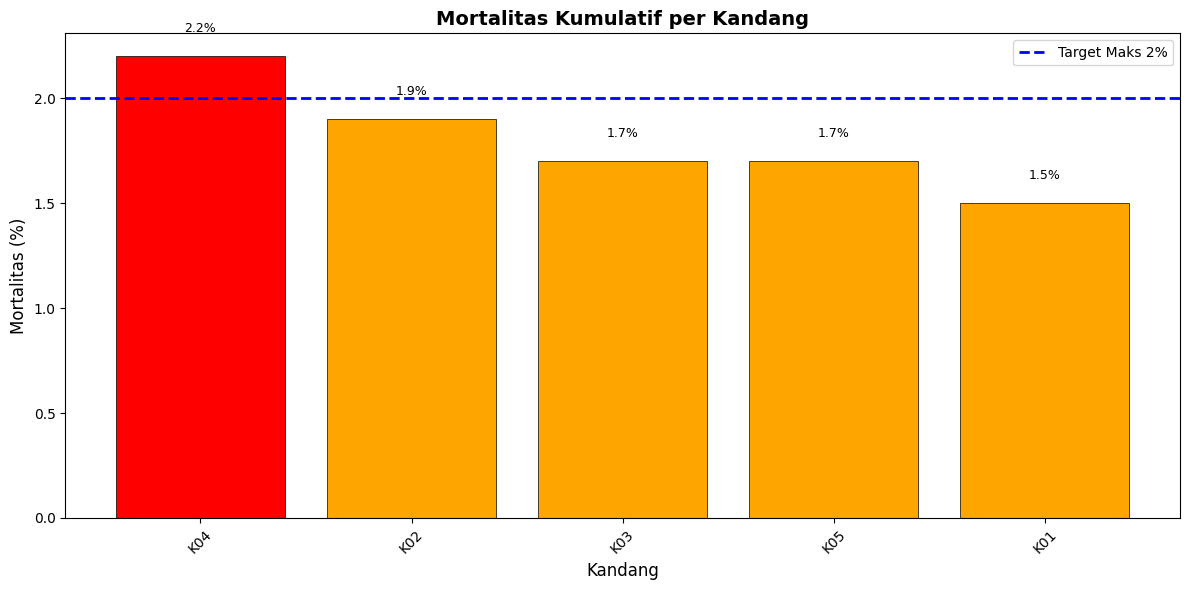

In [84]:
#bar chart kumulatif perkandang
plt.figure(figsize=(12, 6))

warna = []
for m in mati['mortalitas']:
    if m <= 1.0:
        warna.append('green')      
    elif m <= 2.0:
        warna.append('orange')     
    else:
        warna.append('red')        

bars = plt.bar(mati['kandang'], mati['mortalitas'],
               color=warna, edgecolor='black', linewidth=0.5)

plt.axhline(y=2.0, color='blue', linestyle='--', linewidth=2, label='Target Maks 2%')

for bar, val in zip(bars, mati['mortalitas']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.xlabel('Kandang', fontsize=12)
plt.ylabel('Mortalitas (%)', fontsize=12)
plt.title('Mortalitas Kumulatif per Kandang', fontsize=14, fontweight='bold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
#Fcr akhir perkandang 
bobot_rata = df2.groupby(['kandang', 'minggu'])['bobot_gram'].mean().reset_index(name='bobot_rata')
bobot_akhir = bobot_rata[bobot_rata['minggu'] == 16][['kandang', 'bobot_rata']].copy()

total_pakan = df.groupby('kandang')['pakan_kg'].sum().reset_index(name='total_pakan_kg')

populasi_akhir = df[df['minggu'] == 16].groupby('kandang')['populasi_akhir'].last().reset_index(name='populasi_akhir')

fcr_df = total_pakan.merge(populasi_akhir, on='kandang').merge(bobot_akhir, on='kandang')

fcr_df['total_bobot_kg'] = fcr_df['bobot_rata'] * fcr_df['populasi_akhir'] / 1000
fcr_df['FCR_akhir'] = fcr_df['total_pakan_kg'] / fcr_df['total_bobot_kg']

print("="*70)
print("FCR AKHIR PER KANDANG (MINGGU 16)")
print("="*70)
print(fcr_df[['kandang', 'total_pakan_kg', 'populasi_akhir', 'bobot_rata', 'total_bobot_kg', 'FCR_akhir']].round(2).to_string(index=False))
print("="*70)
print(f"Rata-rata FCR semua kandang : {fcr_df['FCR_akhir'].mean():.2f}")

FCR AKHIR PER KANDANG (MINGGU 16)
kandang  total_pakan_kg  populasi_akhir  bobot_rata  total_bobot_kg  FCR_akhir
    K01         6443.45             977     1247.91         1219.20       5.28
    K02         6438.10             972     1255.34         1220.19       5.28
    K03         6476.90             980     1242.63         1217.78       5.32
    K04         6462.38             972     1243.34         1208.53       5.35
    K05         6458.24             976     1241.83         1212.03       5.33
Rata-rata FCR semua kandang : 5.31


In [86]:
#fcr mingguan per kandang
bobot_mingguan = df2.groupby(['kandang', 'minggu'])['bobot_gram'].mean().reset_index(name='bobot_rata')

feed_mingguan = df.groupby(['kandang', 'minggu'])['fi_aktual_gr'].sum().reset_index(name='feed_per_ekor_minggu')

fcr_df = bobot_mingguan.merge(feed_mingguan, on=['kandang', 'minggu'])

fcr_df = fcr_df.sort_values(['kandang', 'minggu'])

fcr_df['bobot_sebelum'] = fcr_df.groupby('kandang')['bobot_rata'].shift(1)

if 0 not in bobot_mingguan['minggu'].values:
    # Asumsikan bobot DOC = 37 g
    fcr_df['bobot_sebelum'] = fcr_df['bobot_sebelum'].fillna(37)
else:
    pass

fcr_df['gain'] = fcr_df['bobot_rata'] - fcr_df['bobot_sebelum']

fcr_df['FCR_minggu'] = fcr_df['feed_per_ekor_minggu'] / fcr_df['gain'].clip(lower=0.1)  # clip untuk hindari pembagian nol

print("="*80)
print(" FCR MINGGUAN PER KANDANG")
print("="*80)
print(fcr_df[['kandang', 'minggu', 'bobot_rata', 'feed_per_ekor_minggu', 'gain', 'FCR_minggu']].round(2).to_string(index=False))


fcr_global = fcr_df.groupby('minggu')['FCR_minggu'].mean().reset_index(name='FCR_rata')
print("\n RATA-RATA FCR PER MINGGU (SEMUA KANDANG):")
print(fcr_global.round(2).to_string(index=False))

 FCR MINGGUAN PER KANDANG
kandang  minggu  bobot_rata  feed_per_ekor_minggu   gain  FCR_minggu
    K01       1      112.21                  96.8  75.21        1.29
    K01       2      193.27                 138.5  81.06        1.71
    K01       3      269.92                 188.0  76.65        2.45
    K01       4      348.97                 236.6  79.04        2.99
    K01       5      437.16                 290.6  88.20        3.29
    K01       6      459.73                 346.1  22.57       15.33
    K01       7      551.72                 386.4  91.99        4.20
    K01       8      619.34                 426.6  67.62        6.31
    K01       9      684.28                 464.4  64.94        7.15
    K01      10      763.55                 496.0  79.27        6.26
    K01      11      866.15                 522.0 102.60        5.09
    K01      12      960.95                 554.8  94.80        5.85
    K01      13     1006.94                 572.5  46.00       12.45
    K01 

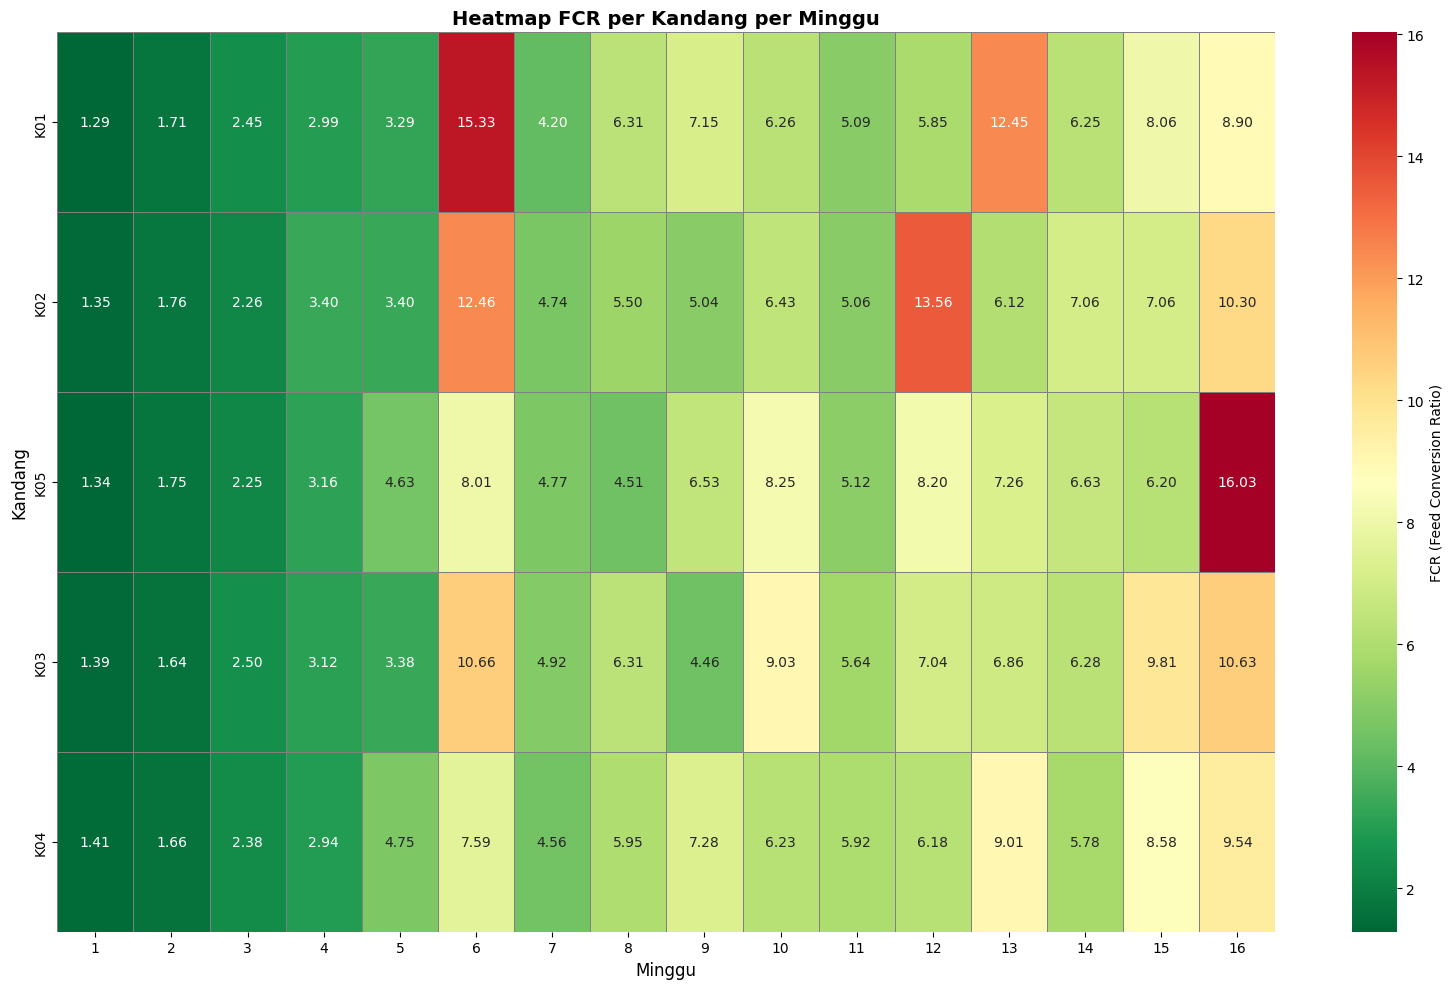

In [87]:
# heatmap fcr perminggu perkandang
pivot_fcr = fcr_df.pivot(index='kandang', columns='minggu', values='FCR_minggu')

pivot_fcr['rata'] = pivot_fcr.mean(axis=1)
pivot_fcr = pivot_fcr.sort_values('rata', ascending=False).drop('rata', axis=1)

plt.figure(figsize=(16, 10))

sns.heatmap(pivot_fcr,
            annot=True,              
            fmt='.2f',                 
            cmap='RdYlGn_r',           
            center=None,             
            vmin=None, vmax=None,    
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'FCR (Feed Conversion Ratio)'})

plt.title('Heatmap FCR per Kandang per Minggu', fontsize=14, fontweight='bold')
plt.xlabel('Minggu', fontsize=12)
plt.ylabel('Kandang', fontsize=12)
plt.tight_layout()
plt.show()

In [88]:

#data mortalitas perminggu perkandang
df_mortalitas = df
if df_mortalitas is not None:
    
    if 'minggu' not in df_mortalitas.columns:
        if 'umur_hari' in df_mortalitas.columns:
            df_mortalitas['minggu'] = (df_mortalitas['umur_hari'] - 1) // 7 + 1
    

    if 'mati' in df_mortalitas.columns:
        df_mortalitas['total_mati'] = df_mortalitas['mati']
    elif 'mati_harian' in df_mortalitas.columns:
        df_mortalitas['total_mati'] = df_mortalitas['mati_harian']
    else:
        print(" Kolom kematian tidak ditemukan")
        df_mortalitas = None

if df_mortalitas is not None:
    mortalitas_mingguan = df_mortalitas.groupby(['kandang', 'minggu'])['total_mati'].sum().reset_index()
    mortalitas_mingguan.columns = ['kandang', 'minggu', 'mati_minggu']
    
    mortalitas_mingguan['mati_kum'] = mortalitas_mingguan.groupby('kandang')['mati_minggu'].cumsum()
    
    mortalitas_mingguan['mortalitas_persen'] = (mortalitas_mingguan['mati_kum'] / 1000) * 100
    
    print(" mortalitas_mingguan berhasil dibuat")
    print(mortalitas_mingguan.head())
else:
    print(" Tidak ada data mortalitas, akan dibuat dummy")
    kandang_list = stat_pullet['kandang'].unique()
    mortalitas_mingguan = []
    for kandang in kandang_list:
        for minggu in range(1, 17):
            if minggu <= 2:
                mati = np.random.poisson(2)
            else:
                mati = np.random.poisson(1)
            mortalitas_mingguan.append([kandang, minggu, mati])
    
    mortalitas_mingguan = pd.DataFrame(mortalitas_mingguan, 
                                       columns=['kandang', 'minggu', 'mati_minggu'])
    mortalitas_mingguan['mati_kum'] = mortalitas_mingguan.groupby('kandang')['mati_minggu'].cumsum()
    mortalitas_mingguan['mortalitas_persen'] = (mortalitas_mingguan['mati_kum'] / 1000) * 100
    print(" Data mortalitas dummy dibuat")

 mortalitas_mingguan berhasil dibuat
  kandang  minggu  mati_minggu  mati_kum  mortalitas_persen
0     K01       1            3         3                0.3
1     K01       2            2         5                0.5
2     K01       3            2         7                0.7
3     K01       4            0         7                0.7
4     K01       5            1         8                0.8


In [89]:
#data menghitung korelasi
stat_pullet = stat_pullet.reset_index()
df_keseragaman  = keseragaman_perkandang_perminggu

cv_minggu6 = stat_pullet[stat_pullet['minggu'] == 6][['kandang', 'cv']].copy()
cv_minggu6.columns = ['kandang', 'cv_minggu6']

keseragaman_minggu8 = df_keseragaman[df_keseragaman['minggu'] == 8][['kandang', 'keseragaman']].copy()
keseragaman_minggu8.columns = ['kandang', 'keseragaman_minggu8']

keseragaman_minggu16 = df_keseragaman[df_keseragaman['minggu'] == 16][['kandang', 'keseragaman']].copy()
keseragaman_minggu16.columns = ['kandang', 'keseragaman_minggu16']

mortalitas_awal = mortalitas_mingguan[mortalitas_mingguan['minggu'] <= 4].groupby('kandang').agg({
    'mati_kum': 'max',
    'mortalitas_persen': 'max'
}).reset_index()
mortalitas_awal.columns = ['kandang', 'mati_kum_minggu1_4', 'mortalitas_persen_minggu1_4']

if 'feed_intake' in stat_pullet.columns:
    feed_minggu8 = stat_pullet[stat_pullet['minggu'] == 8][['kandang', 'feed_intake']].copy()
    feed_minggu8.columns = ['kandang', 'feed_intake_minggu8']
else:

    kandang_list = stat_pullet['kandang'].unique()
    feed_minggu8 = pd.DataFrame({
        'kandang': kandang_list,
        'feed_intake_minggu8': np.random.uniform(60, 70, len(kandang_list))
    })


bobot_minggu16 = stat_pullet[stat_pullet['minggu'] == 16][['kandang', 'bobot_rata']].copy()
bobot_minggu16.columns = ['kandang', 'bobot_minggu16']

kandang_list = stat_pullet['kandang'].unique()
fcr_akhir = pd.DataFrame({
    'kandang': kandang_list,
    'fcr': np.random.uniform(2.2, 2.8, len(kandang_list))
})

data_korelasi = cv_minggu6.merge(keseragaman_minggu8, on='kandang', how='outer')
data_korelasi = data_korelasi.merge(keseragaman_minggu16, on='kandang', how='outer')
data_korelasi = data_korelasi.merge(mortalitas_awal, on='kandang', how='outer')
data_korelasi = data_korelasi.merge(feed_minggu8, on='kandang', how='outer')
data_korelasi = data_korelasi.merge(bobot_minggu16, on='kandang', how='outer')
data_korelasi = data_korelasi.merge(fcr_akhir, on='kandang', how='outer')

print(" Data korelasi")
print(data_korelasi.head())
print(f"\nJumlah kandang: {len(data_korelasi)}")

 Data korelasi
  kandang  cv_minggu6  keseragaman_minggu8  keseragaman_minggu16  \
0     K01   11.689706            63.265306             72.916667   
1     K02   10.617458            68.750000             77.083333   
2     K03    9.501267            57.142857             77.551020   
3     K04    9.568682            73.469388             68.750000   
4     K05    8.100010            75.510204             77.083333   

   mati_kum_minggu1_4  mortalitas_persen_minggu1_4  feed_intake_minggu8  \
0                   7                          0.7            62.641438   
1                   6                          0.6            63.810251   
2                  12                          1.2            62.850675   
3                  10                          1.0            63.102608   
4                   7                          0.7            64.034583   

   bobot_minggu16       fcr  
0     1247.906250  2.619628  
1     1255.339583  2.430564  
2     1242.630612  2.775634  
3    

KORELASI 1: CV MINGGU 6 vs KESERAGAMAN MINGGU 16
Koefisien korelasi (r): -0.241
P-value: 0.6961
Jumlah kandang: 5
Korelasi tidak signifikan secara statistik


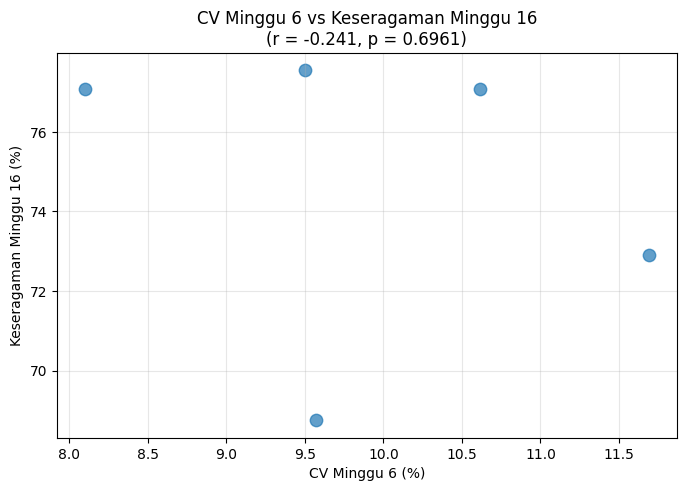

In [90]:
# korelasi minggu 6 vs keseragaman minggu 16
df_clean = data_korelasi[['cv_minggu6', 'keseragaman_minggu16']].dropna()
x = df_clean['cv_minggu6']
y = df_clean['keseragaman_minggu16']

if len(df_clean) > 2:
    r, p = stats.pearsonr(x, y)
    print("="*50)
    print("KORELASI 1: CV MINGGU 6 vs KESERAGAMAN MINGGU 16")
    print("="*50)
    print(f"Koefisien korelasi (r): {r:.3f}")
    print(f"P-value: {p:.4f}")
    print(f"Jumlah kandang: {len(df_clean)}")
    
    if p < 0.05:
        if r < 0:
            print(" Interpretasi: CV tinggi di minggu 6 berkorelasi NEGATIF dengan keseragaman akhir")
        else:
            print(" Interpretasi: CV tinggi di minggu 6 berkorelasi POSITIF dengan keseragaman akhir")
    else:
        print("Korelasi tidak signifikan secara statistik")
    
    # Plot
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, s=80, alpha=0.7)
    plt.xlabel('CV Minggu 6 (%)')
    plt.ylabel('Keseragaman Minggu 16 (%)')
    plt.title(f'CV Minggu 6 vs Keseragaman Minggu 16\n(r = {r:.3f}, p = {p:.4f})')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Data tidak cukup untuk korelasi")

KORELASI 2: KESERAGAMAN MINGGU 8 vs FCR
Koefisien korelasi (r): -0.810
P-value: 0.0965


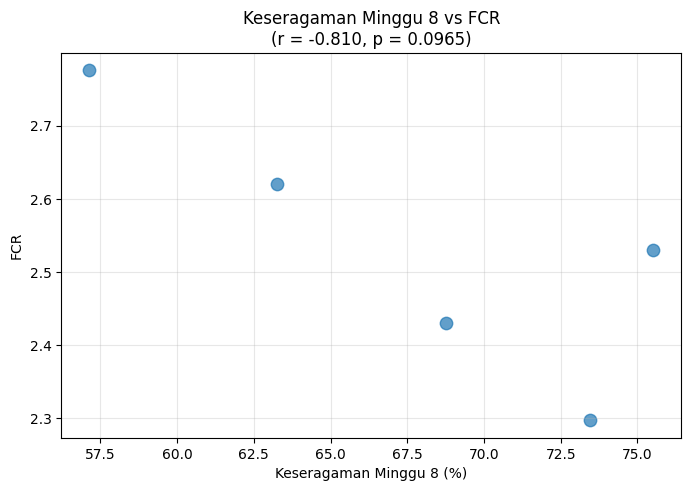

In [91]:
#korelasi keseragaman minggu 8 vs FCR
df_clean = data_korelasi[['keseragaman_minggu8', 'fcr']].dropna()
x = df_clean['keseragaman_minggu8']
y = df_clean['fcr']

if len(df_clean) > 2:
    r, p = stats.pearsonr(x, y)
    print("="*50)
    print("KORELASI 2: KESERAGAMAN MINGGU 8 vs FCR")
    print("="*50)
    print(f"Koefisien korelasi (r): {r:.3f}")
    print(f"P-value: {p:.4f}")
    
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, s=80, alpha=0.7)
    plt.xlabel('Keseragaman Minggu 8 (%)')
    plt.ylabel('FCR')
    plt.title(f'Keseragaman Minggu 8 vs FCR\n(r = {r:.3f}, p = {p:.4f})')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Data tidak cukup untuk korelasi")

KORELASI 3: MORTALITAS AWAL vs KESERAGAMAN AKHIR
Koefisien korelasi (r): -0.152
P-value: 0.8072


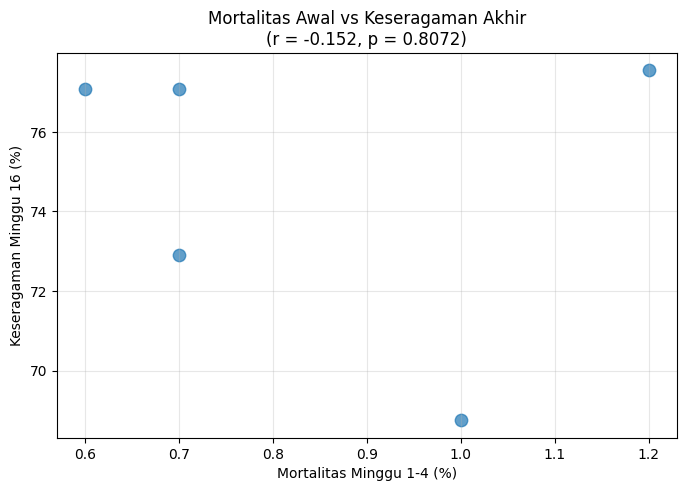

In [92]:
# Korelasi mortalitas awal vs keseragaman akhir
df_clean = data_korelasi[['mortalitas_persen_minggu1_4', 'keseragaman_minggu16']].dropna()
x = df_clean['mortalitas_persen_minggu1_4']
y = df_clean['keseragaman_minggu16']

if len(df_clean) > 2:
    r, p = stats.pearsonr(x, y)
    print("="*50)
    print("KORELASI 3: MORTALITAS AWAL vs KESERAGAMAN AKHIR")
    print("="*50)
    print(f"Koefisien korelasi (r): {r:.3f}")
    print(f"P-value: {p:.4f}")
    
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, s=80, alpha=0.7)
    plt.xlabel('Mortalitas Minggu 1-4 (%)')
    plt.ylabel('Keseragaman Minggu 16 (%)')
    plt.title(f'Mortalitas Awal vs Keseragaman Akhir\n(r = {r:.3f}, p = {p:.4f})')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Data tidak cukup untuk korelasi")

KORELASI 4: FEED INTAKE vs BOBOT AKHIR
Koefisien korelasi (r): 0.183
P-value: 0.7683


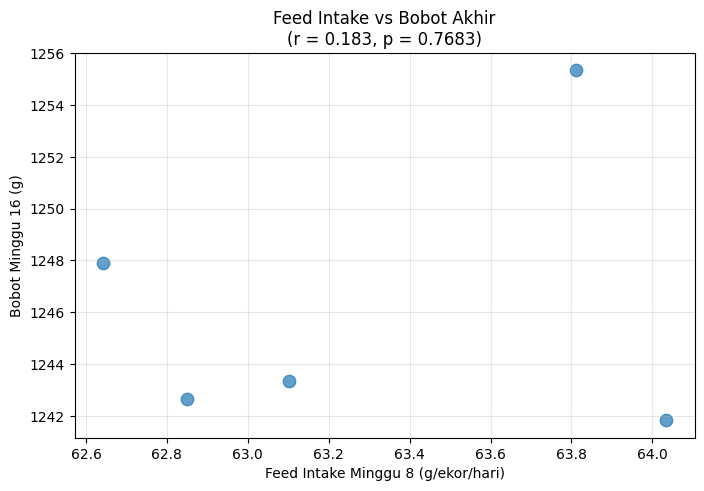

In [93]:
# korelasi feed intake vs bobot akhir
df_clean = data_korelasi[['feed_intake_minggu8', 'bobot_minggu16']].dropna()
x = df_clean['feed_intake_minggu8']
y = df_clean['bobot_minggu16']

if len(df_clean) > 2:
    r, p = stats.pearsonr(x, y)
    print("="*50)
    print("KORELASI 4: FEED INTAKE vs BOBOT AKHIR")
    print("="*50)
    print(f"Koefisien korelasi (r): {r:.3f}")
    print(f"P-value: {p:.4f}")
    
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, s=80, alpha=0.7)
    plt.xlabel('Feed Intake Minggu 8 (g/ekor/hari)')
    plt.ylabel('Bobot Minggu 16 (g)')
    plt.title(f'Feed Intake vs Bobot Akhir\n(r = {r:.3f}, p = {p:.4f})')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Data tidak cukup untuk korelasi")

In [94]:
# Buat ringkasan semua korelasi
hasil_korelasi = []

def hitung_korelasi_safe(x, y, nama):
    df_clean = data_korelasi[[x, y]].dropna()
    if len(df_clean) > 2:
        r, p = stats.pearsonr(df_clean[x], df_clean[y])
        return [nama, round(r,3), round(p,4), len(df_clean)]
    else:
        return [nama, None, None, 0]

hasil_korelasi.append(hitung_korelasi_safe('cv_minggu6', 'keseragaman_minggu16', 'CV M6 vs Keseragaman M16'))
hasil_korelasi.append(hitung_korelasi_safe('keseragaman_minggu8', 'fcr', 'Keseragaman M8 vs FCR'))
hasil_korelasi.append(hitung_korelasi_safe('mortalitas_persen_minggu1_4', 'keseragaman_minggu16', 'Mortalitas Awal vs Keseragaman Akhir'))
hasil_korelasi.append(hitung_korelasi_safe('feed_intake_minggu8', 'bobot_minggu16', 'Feed Intake vs Bobot Akhir'))

df_hasil = pd.DataFrame(hasil_korelasi, columns=['Parameter', 'r', 'p-value', 'n'])
print("\n" + "="*60)
print("RINGKASAN KORELASI")
print("="*60)
print(df_hasil.to_string(index=False))


RINGKASAN KORELASI
                           Parameter      r  p-value  n
            CV M6 vs Keseragaman M16 -0.241   0.6961  5
               Keseragaman M8 vs FCR -0.810   0.0965  5
Mortalitas Awal vs Keseragaman Akhir -0.152   0.8072  5
          Feed Intake vs Bobot Akhir  0.183   0.7683  5


In [95]:
df_hasil

,Parameter,r,p-value,n
0,CV M6 vs Keseragaman M16,-0.241,0.6961,5
1,Keseragaman M8 vs FCR,-0.810,0.0965,5
2,Mortalitas Awal vs Keseragaman Akhir,-0.152,0.8072,5
3,Feed Intake vs Bobot Akhir,0.183,0.7683,5
